In [9]:
import numpy as np
import math
import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mplcolors
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
from matplotlib.ticker import FixedLocator
from matplotlib.ticker import AutoMinorLocator
from MyPlotRecipe.SharedX import ShareXaxis
from UniversalColor import UniversalColor
from legend_shadow import legend_shadow
from scipy.io import readsav
from scipy.optimize import curve_fit
import spiceypy as spice

import JupiterMag as jm
import Leadangle_wave as LeadA

from Leadangle_fit_JunoUVS import Obsresults
from Leadangle_fit_JunoUVS import viewingangle
from Leadangle_fit_JunoUVS import calc_eqlead
from Leadangle_fit_JunoUVS import moonS3wlon_arr
from Leadangle_fit_JunoUVS import local_time_moon

import os

spice.furnsh('kernel/cassMetaK.txt')

UC = UniversalColor()
UC.set_palette()

In [10]:
# Input about Juno observation
TARGET_MOON = 'Ganymede'
TARGET_FP = ['MAW', 'TEB']
PJ_ALL = [1, 3]+np.arange(4, 68+1, 1).tolist()
USE_BACKTRACED = True

Zi = 1.4    # ION CHARGE [C] !!! CONSTANT !!!
Te = 20     # ELECTRON TEMPERATURE [eV] !!! CONSTANT !!!

In [11]:
# %% Constants
MU0 = 1.26E-6            # 真空中の透磁率
AMU2KG = 1.66E-27        # 原子質量をkgに変換するファクタ [kg]
RJ = 71492E+3            # JUPITER RADIUS [m]
MJ = 1.90E+27            # JUPITER MASS [kg]
C = 2.99792E+8           # LIGHT SPEED [m/s]
G = 6.67E-11             # 万有引力定数  [m^3 kg^-1 s^-2]

Psyn_io = (12.89)*3600      # Moon's synodic period [sec]
Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

In [12]:
# %% Data from Connerney+2020: PJ index
con20_pj_idx = np.array([1, 3, 4, 5, 6,
                         7, 8, 9, 10, 11,
                         12, 13, 14, 15, 16,
                         17, 18, 19, 20, 21,
                         22, 23, 24], dtype=int)


# %% Data from Connerney+2020: Current constant [nT]
con20_mu_i_tot = np.array([150.1, 137.8, 127.2, 129.1, 130.1,
                           142.3, 140.1, 143.8, 137.0, 141.4,
                           124.2, 148.9, 145.3, 144.8, 149.9,
                           132.1, 133.5, 152.9, 138.5, 138.8,
                           156.1, 141.4, 146.3])


# %% Data from Connerney+2020: Radial current constant [MA]
con20_mu_i_rho = np.array([35.2, 14.6, 7.7, 11.5, 20.8,
                           20.2, 12.2, 21.1, 20.9, 10.7,
                           26.26, 16.4, 12.0, 19.6, 12.0,
                           13.6, 20.0, 12.8, 16.0, 17.3,
                           9.9, 16.1, 10.3])

In [13]:
PJ_LIST = con20_pj_idx[:-1].tolist()

In [14]:
wlon_fp, err_wlon_fp, lat_fp, err_lat_fp, moon_S3wlon, et_fp, hem_fp, pj_fp = Obsresults(
    PJ_LIST, TARGET_MOON, TARGET_FP, TARGET_HEM='both', FLIP=False
)

# Time: t0, the observation time
_, _, _, _, _, _, moon_S3wlon = moonS3wlon_arr(et_fp, TARGET_MOON)

eqlead_fp, eqlead_fp_0, eqlead_fp_1, wlon_fp_eq = calc_eqlead(wlon_fp,
                                                              err_wlon_fp,
                                                              lat_fp,
                                                              err_lat_fp,
                                                              hem_fp,
                                                              moon_S3wlon,
                                                              TARGET_MOON)

data_dir = 'data/Backtraced_Con2020/'
rho_eq = np.zeros(3)
phi_eq = np.zeros(3)
thick_coef_best = np.zeros(3)
for i in range(len(PJ_LIST)):
    data = np.loadtxt(
        data_dir+'PJ'+str(PJ_LIST[i]).zfill(2)+'/'+TARGET_MOON[0]+'FP_info_v900km.txt')
    rho_eq = np.append(rho_eq, data[0, :])
    phi_eq = np.append(phi_eq, data[1, :])
    thick_coef_best = np.append(thick_coef_best, data[5, :])

data_dir = 'data/Backtraced_AZI_CURRENT/'
azi_currnet_0 = np.zeros(3)
azi_currnet_1 = np.zeros(3)
azi_currnet_2 = np.zeros(3)
for i in range(len(PJ_LIST)):
    data = np.loadtxt(
        data_dir+'PJ'+str(PJ_LIST[i]).zfill(2)+'/'+TARGET_MOON[0]+'FP_info_v900km_0.txt')
    azi_currnet_0 = np.append(azi_currnet_0, data[5, :])
    data = np.loadtxt(
        data_dir+'PJ'+str(PJ_LIST[i]).zfill(2)+'/'+TARGET_MOON[0]+'FP_info_v900km_1.txt')
    azi_currnet_1 = np.append(azi_currnet_1, data[5, :])
    data = np.loadtxt(
        data_dir+'PJ'+str(PJ_LIST[i]).zfill(2)+'/'+TARGET_MOON[0]+'FP_info_v900km_2.txt')
    azi_currnet_2 = np.append(azi_currnet_2, data[5, :])

rho_eq = rho_eq[3:]     # [RJ]
phi_eq = phi_eq[3:]     # west longitude [deg]
thick_coef_best = thick_coef_best[3:]   # best-fit thickness coefficient
azi_currnet_0 = azi_currnet_0[3:]
azi_currnet_1 = azi_currnet_1[3:]
azi_currnet_2 = azi_currnet_2[3:]
# Footprint equatorial lead angle [deg]
eqlead_fp = np.mod(moon_S3wlon-phi_eq, 360.0)

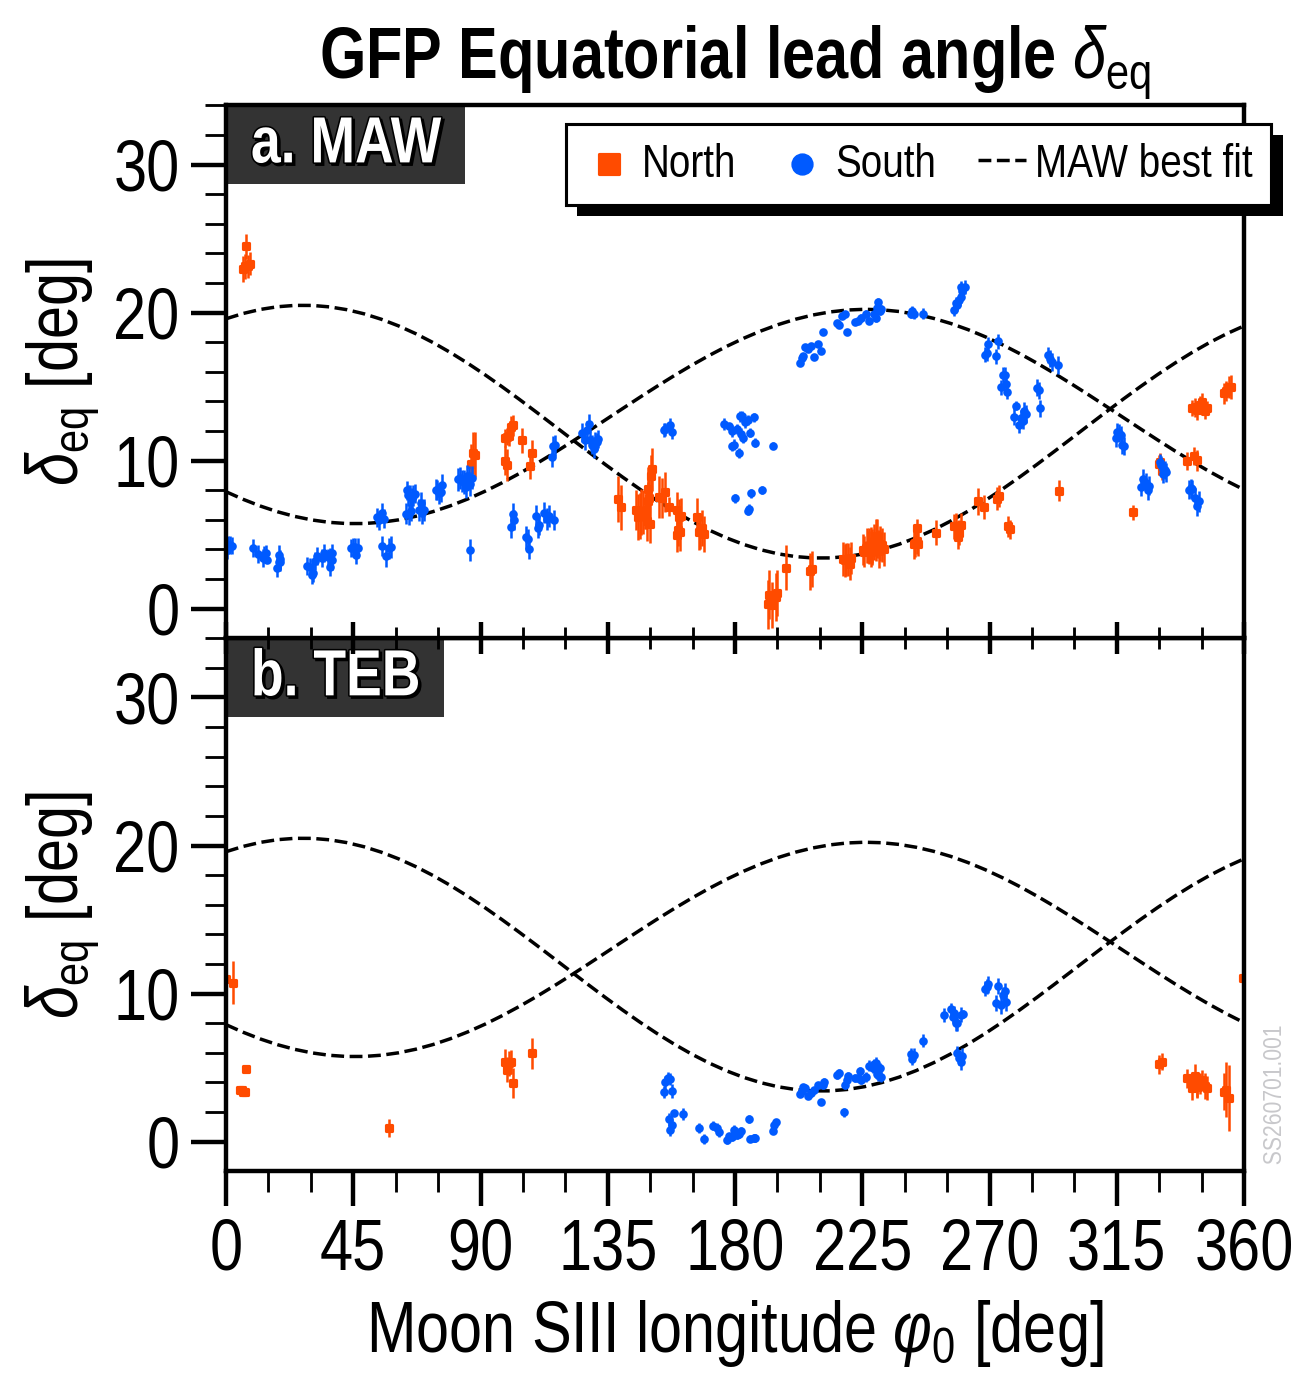

In [15]:
# %% ===============================================================================
# 横軸: Moon System III longitude [deg] / 縦軸: Footprint equatorial lead angle [deg]
# ==================================================================================
fig_id = 'SS260701.001'
F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'
F.wspace = 0.1

F.set_figparams(nrows=2, figsize=(6.0, 6.0), ticksize=1.5,
                dpi='L')
F.initialize()
F.panelname = [' a. MAW ', ' b. TEB ']

F.set_xaxis(label=r'Moon SIII longitude $\varphi_0$ [deg]',
            min=0, max=360,
            ticks=np.arange(0, 360+1, 45),
            ticklabels=np.arange(0, 360+1, 45),
            minor_num=3)

# F.fig.set_rasterized(True)
TARGET_MOON_LIST = ['Ganymede', 'Ganymede']
TARGET_FP_LIST = [['MAW'], ['TEB']]
for i in range(2):
    TARGET_MOON = TARGET_MOON_LIST[i]

    ymax = 1
    if TARGET_MOON == 'Io':
        ymin = -1
        ymax = 11
        dy = 5
    elif TARGET_MOON == 'Europa':
        ymin = -2
        ymax = 17
        dy = 5
    elif TARGET_MOON == 'Ganymede':
        ymin = -2
        ymax = 34
        dy = 10

    Psyn = Psyn_io

    F.set_yaxis(ax_idx=i, label=r'$\delta_{\rm eq}$ [deg]',
                min=ymin, max=ymax,
                ticks=np.arange(0, ymax+1, dy),
                ticklabels=np.arange(0, ymax+1, dy),
                minor_num=5)

for j in range(2):
    # All PJ
    north = np.where((hem_fp == -(1+100*j)))
    F.ax[j].scatter(moon_S3wlon[north], eqlead_fp[north],
                    color=UC.red, s=3.0,
                    marker='s',
                    label='North',
                    zorder=0.9)
    F.ax[j].errorbar(moon_S3wlon[north], eqlead_fp[north],
                     yerr=np.abs(eqlead_fp_0[north]),
                     linewidth=0., markersize=0,
                     elinewidth=0.8, color=UC.red,
                     zorder=0.9)

    # All PJ
    south = np.where((hem_fp == 1+100*j))
    F.ax[j].scatter(moon_S3wlon[south], eqlead_fp[south],
                    color=UC.blue, s=3.0,
                    label='South',
                    zorder=0.9)
    F.ax[j].errorbar(moon_S3wlon[south], eqlead_fp[south],
                     yerr=np.abs(eqlead_fp_0[south]),
                     linewidth=0., markersize=0,
                     elinewidth=0.8, color=UC.blue,
                     zorder=0.9)

    # From Hue+ 2023
    if TARGET_MOON == 'Io':
        lam = np.radians(np.linspace(0, 360, 60))
        delta_Hue_N = 4.16 + 2.48*np.cos(lam) \
            + 0.54*np.sin(lam) + 0.24*np.cos(2*lam) + 0.271*np.sin(2*lam)
        delta_Hue_S = 4.19 - 1.81*np.cos(1.001*lam) \
            - 0.72*np.sin(1.001*lam) + 0.336 * \
            np.cos(2*1.001*lam) - 0.15*np.sin(2*1.001*lam)
    elif TARGET_MOON == 'Europa':
        lam = np.radians(np.linspace(0, 360, 60))
        delta_Hue_N = 5.99 + 3.23*np.cos(lam) \
            + 1.65*np.sin(lam)
        delta_Hue_S = 7.10 - 3.46*np.cos(1.002*lam) \
            - 0.34*np.sin(1.002*lam)
    elif TARGET_MOON == 'Ganymede':
        lam = np.radians(np.linspace(0, 360, 60))
        delta_Hue_N = 11.95 + 7.63*np.cos(0.9828*lam) \
            + 3.85*np.sin(0.982*lam)
        delta_Hue_S = 12.98 - 5.08*np.cos(0.996*lam) \
            - 5.16*np.sin(0.996*lam)

    F.ax[j].plot(np.degrees(lam), delta_Hue_N,
                 linestyle='--', linewidth=1.1, color='k',
                 label='MAW best fit', zorder=0.5)
    F.ax[j].plot(np.degrees(lam), delta_Hue_S,
                 linestyle='--', linewidth=1.1, color='k',
                 zorder=0.5)

F.ax[0].set_title(
    TARGET_MOON[0]+'FP'+r' Equatorial lead angle $\delta_{\rm eq}$', fontsize=F.fontsize, weight='bold')

legend = F.legend(ax_idx=0, bbox_to_anchor=(1.05, 1.01),
                  ncol=3, markerscale=3.5,
                  fontsize_scale=0.65, textcolor=False, handletextpad=0.2)
legend_shadow(fig=F.fig, ax=F.ax[0], legend=legend, d=1.0)

F.manage(ax_idx=1, id=fig_id, color=UC.lightgray)

# F.fig.savefig('MAW_TEB_'+TARGET_MOON+'.pdf', bbox_inches='tight')
plt.show()

del F

/usr/local/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/var/folders/1k/lwlgtqdd2cl3xly6vnmxl86w0000gn/T/ipykernel_53348/1406011515.py:23: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  selected_time = np.array(selected_time, dtype=np.datetime64)


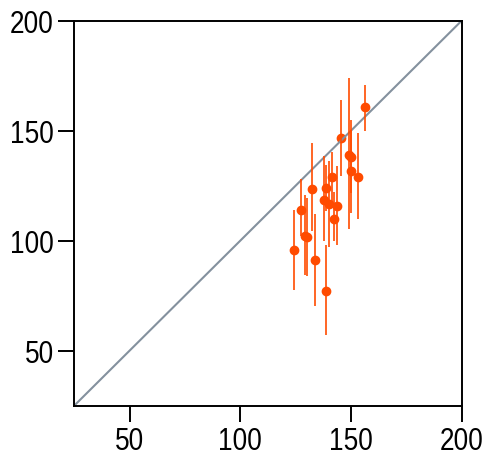

In [21]:
# Disk thickness
selected_time = []
azi_currnet_0_ave = np.zeros(len(PJ_LIST))
azi_currnet_1_ave = np.zeros(len(PJ_LIST))
azi_currnet_2_ave = np.zeros(len(PJ_LIST))
for i in range(len(PJ_LIST)):
    select_pj = np.where(pj_fp == PJ_LIST[i])
    fp_type = hem_fp[select_pj]
    view = np.zeros(fp_type.size)
    view_MAW = viewingangle(PJ_LIST[i], TARGET_MOON, 'MAW')
    view_TEB = viewingangle(PJ_LIST[i], TARGET_MOON, 'TEB')
    view = np.hstack((view_MAW, view_TEB))
    azi_currnet_0_ave[i] = np.average(
        azi_currnet_0[select_pj][np.where(view <= 30.0)])
    azi_currnet_1_ave[i] = np.average(
        azi_currnet_1[select_pj][np.where(view <= 30.0)])
    azi_currnet_2_ave[i] = np.average(
        azi_currnet_2[select_pj][np.where(view <= 30.0)])
    selected_time += [spice.et2datetime(
        np.median(et_fp[select_pj][np.where(view <= 30.0)]))]

isnan = np.isnan(azi_currnet_0_ave)
selected_time = np.array(selected_time, dtype=np.datetime64)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(25, 200)
ax.set_ylim(25, 200)
ax.plot([-300.0, 300.0], [-300.0, 300.0], color=UC.gray)
ax.scatter(con20_mu_i_tot[:-1], azi_currnet_0_ave)
ax.errorbar(x=con20_mu_i_tot[:-1], y=azi_currnet_0_ave,
            elinewidth=1.2, linewidth=0, markersize=0, color=UC.red,
            yerr=np.array([abs(azi_currnet_1_ave-azi_currnet_0_ave),
                           abs(azi_currnet_2_ave-azi_currnet_0_ave)]))
plt.show()

time format 0
time format 1


/usr/local/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/Caskroom/miniforge/base/envs/py3104/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/var/folders/1k/lwlgtqdd2cl3xly6vnmxl86w0000gn/T/ipykernel_60443/259745752.py:177: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  selected_time = np.array(selected_time, dtype=np.datetime64)


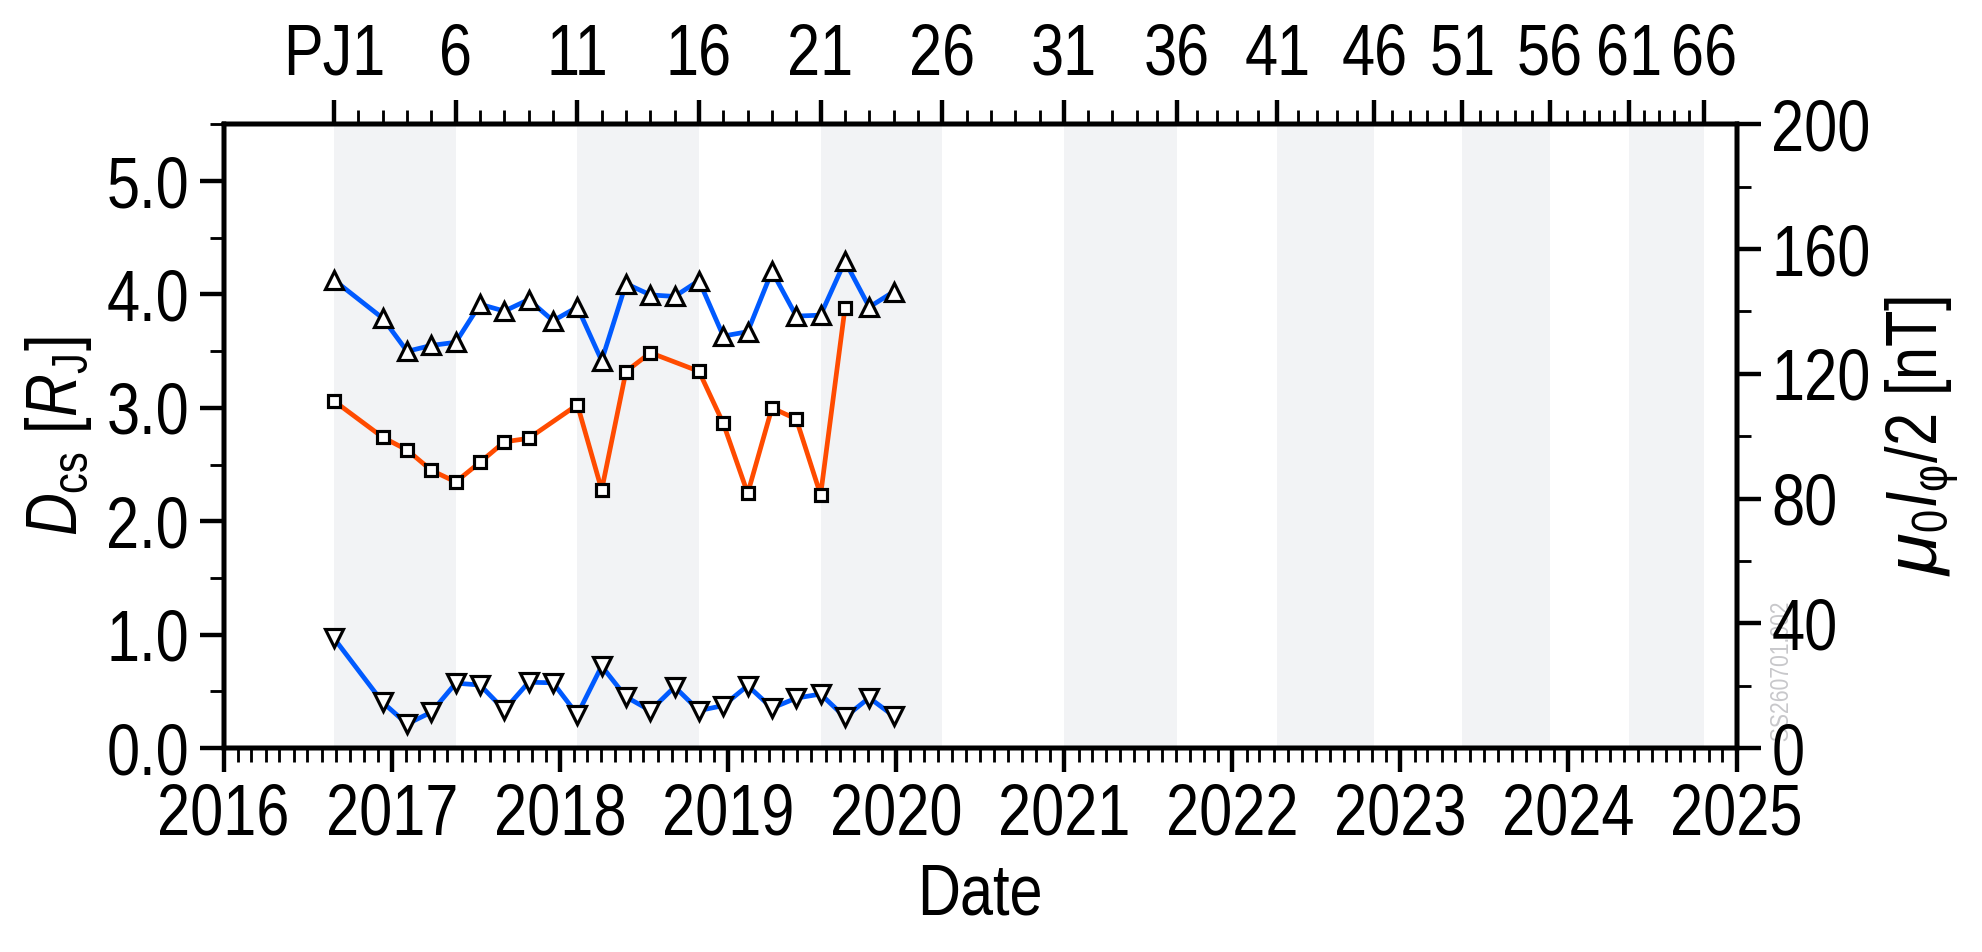

In [8]:
# %% ===============================================================================
# 横軸: Dates / 縦軸: Magnetodisk thickness
# ==================================================================================
fig_id = 'SS260701.002'

JUNO_PJ_TIMES = [
    datetime.datetime.strptime(
        '2016-08-27 12:50', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2016-10-19 18:10', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2016-12-11 17:03', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-02-02 12:57', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-03-27 08:51', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-05-19 06:00', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-07-11 01:54', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-09-01 21:48', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-10-24 17:42', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2017-12-16 17:56', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-02-07 13:51', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-04-01 09:45', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-05-24 05:39', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-07-16 05:17', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-09-07 01:11', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-10-29 21:05', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2018-12-21 16:59', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-02-12 17:34', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-04-06 12:14', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-05-29 08:08', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-07-21 04:02', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-09-12 03:40', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-11-03 22:18', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2019-12-26 17:36', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-02-17 17:51', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-04-10 13:47', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-06-02 10:20', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-07-25 06:15', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-09-16 02:10', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-11-08 01:49', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2020-12-30 21:45', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime(
        '2021-02-21 17:40', '%Y-%m-%d %H:%M'),
    datetime.datetime.strptime('2021-04-15', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-06-08', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-07-21', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-09-02', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-10-16', '%Y-%m-%d'),
    datetime.datetime.strptime('2021-11-29', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-01-12', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-02-25', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-04-09', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-05-23', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-07-05', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-08-17', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-09-29', '%Y-%m-%d'),
    datetime.datetime.strptime('2022-11-06', '%Y-%m-%d'),  # PJ46
    datetime.datetime.strptime('2022-12-15', '%Y-%m-%d'),  # PJ47
    datetime.datetime.strptime('2023-01-22', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-03-01', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-04-08', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-05-16', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-06-23', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-07-31', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-09-07', '%Y-%m-%d'),  # PJ54
    datetime.datetime.strptime('2023-10-15', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-11-22', '%Y-%m-%d'),
    datetime.datetime.strptime('2023-12-30', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-02-04', '%Y-%m-%d'),  # PJ58
    datetime.datetime.strptime('2024-03-07', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-04-09', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-05-12', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-06-14', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-07-16', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-08-18', '%Y-%m-%d'),  # PJ64
    datetime.datetime.strptime('2024-09-20', '%Y-%m-%d'),
    datetime.datetime.strptime('2024-10-23', '%Y-%m-%d'),  # PJ66
]
JUNO_PJ_LABELS = ['PJ1', '', '', '', '',
                  '6', '', '', '', '',
                  '11', '', '', '', '',
                  '16', '', '', '', '',
                  '21', '', '', '', '',
                  '26', '', '', '', '',
                  '31', '', '', '', '',
                  '36', '', '', '', '',
                  '41', '', '', '', '',
                  '46', '', '', '', '',
                  '51', '', '', '', '',
                  '56', '', '', '', '',
                  '61', '', '', '', '',
                  '66']

F = ShareXaxis()
F.fontsize = 23
F.fontname = 'Liberation Sans Narrow'

F.set_figparams(nrows=1, figsize=(8.2, 4.0), dpi='L')
F.initialize()
# F.panelname = [' a. Io ', ' b. Europa ', ' c. Ganymede ']

sxmin = '2016-01-01'
sxmax = '2025-01-01'
xmin = datetime.datetime.strptime(sxmin, '%Y-%m-%d')
xmax = datetime.datetime.strptime(sxmax, '%Y-%m-%d')
xticks = [datetime.datetime.strptime('2016-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2017-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2018-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2019-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2020-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2021-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2022-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2023-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2024-01-01', '%Y-%m-%d'),
          datetime.datetime.strptime('2025-01-01', '%Y-%m-%d')]
xticklabels = ['2016', '2017', '2018', '2019', '2020',
               '2021', '2022', '2023', '2024', '2025']
F.set_xaxis(label='Date',
            min=xmin, max=xmax,
            ticks=xticks,
            ticklabels=xticklabels,
            minor_num=12)
F.ax.minorticks_off()
F.ax.xaxis.set_minor_locator(mdates.MonthLocator())
ticklabels = F.ax.get_xticklabels()
ticklabels[0].set_ha('center')
F.set_yaxis(ax_idx=0,
            label=r'$D_{\rm cs}$ [$R_{\rm J}$]',
            min=0, max=5.5,
            ticks=np.linspace(0, 5, 6),
            ticklabels=np.linspace(0, 5, 6),
            minor_num=2)

# Disk thickness
selected_time = []
disk_thickness = np.zeros(len(PJ_LIST))
for i in range(len(PJ_LIST)):
    select_pj = np.where(pj_fp == PJ_LIST[i])
    fp_type = hem_fp[select_pj]
    view = np.zeros(fp_type.size)
    view_MAW = viewingangle(PJ_LIST[i], TARGET_MOON, 'MAW')
    view_TEB = viewingangle(PJ_LIST[i], TARGET_MOON, 'TEB')
    view = np.hstack((view_MAW, view_TEB))
    disk_thickness[i] = np.average(
        thick_coef_best[select_pj][np.where(view <= 30.0)])
    selected_time += [spice.et2datetime(
        np.median(et_fp[select_pj][np.where(view <= 30.0)]))]

isnan = np.isnan(disk_thickness)
selected_time = np.array(selected_time, dtype=np.datetime64)
disk_thickness[~isnan]
F.ax.plot(selected_time[~isnan], disk_thickness[~isnan]*3.6,
          marker='s', color=UC.red, markersize=4,
          markeredgecolor='k', markerfacecolor='w', zorder=2)

# Azimuthal current constant [RJ]
selected_time = []
for i in range(con20_pj_idx.size):
    selected_time += [JUNO_PJ_TIMES[con20_pj_idx[i]-1]]
Rax = F.ax.twinx()
Rax.set_ylabel(r'$\mu_0 I_{\rm \varphi}/2$ [nT]')
Rax.set_ylim(0, 200)
Rax.set_yticks(np.linspace(0, 200, 6))
Rax.yaxis.set_minor_locator(AutoMinorLocator(2))  # minor ticks
Rax.plot(selected_time, con20_mu_i_tot,
         marker='^', color=UC.blue,
         markeredgecolor='k', markerfacecolor='w',)
Rax.plot(selected_time, con20_mu_i_rho,
         marker='v', color=UC.blue,
         markeredgecolor='k', markerfacecolor='w',)

# PJ numbers on the top horizontal axis
PJax = F.ax.twiny()
PJax.set_xlim(xmin, xmax)
PJax.set_xticks(JUNO_PJ_TIMES[::5])
PJax.set_xticklabels(JUNO_PJ_LABELS[::5])
PJax.xaxis.set_minor_locator(FixedLocator(mdates.date2num(JUNO_PJ_TIMES)))
PJax.tick_params('y', grid_zorder=-10)

# Shades in each 5 perijove
F.ax.axvspan(JUNO_PJ_TIMES[0], JUNO_PJ_TIMES[5],
             fc=UC.gray, ec=None, alpha=0.10)
F.ax.axvspan(JUNO_PJ_TIMES[10], JUNO_PJ_TIMES[15],
             fc=UC.gray, ec=None, alpha=0.10)
F.ax.axvspan(JUNO_PJ_TIMES[20], JUNO_PJ_TIMES[25],
             fc=UC.gray, ec=None, alpha=0.10)
F.ax.axvspan(JUNO_PJ_TIMES[30], JUNO_PJ_TIMES[35],
             fc=UC.gray, ec=None, alpha=0.10)
F.ax.axvspan(JUNO_PJ_TIMES[40], JUNO_PJ_TIMES[45],
             fc=UC.gray, ec=None, alpha=0.10)
F.ax.axvspan(JUNO_PJ_TIMES[50], JUNO_PJ_TIMES[55],
             fc=UC.gray, ec=None, alpha=0.10)
F.ax.axvspan(JUNO_PJ_TIMES[60], JUNO_PJ_TIMES[65],
             fc=UC.gray, ec=None, alpha=0.10)

F.manage(ax_idx=1, id=fig_id, color=UC.lightgray)

# F.fig.savefig('MAW_TEB_'+TARGET_MOON+'.pdf', bbox_inches='tight')
plt.show()

del F